# 302.4. Photometry in crowded fields

<div style="max-width:300px; float: left; margin-right: 1em">

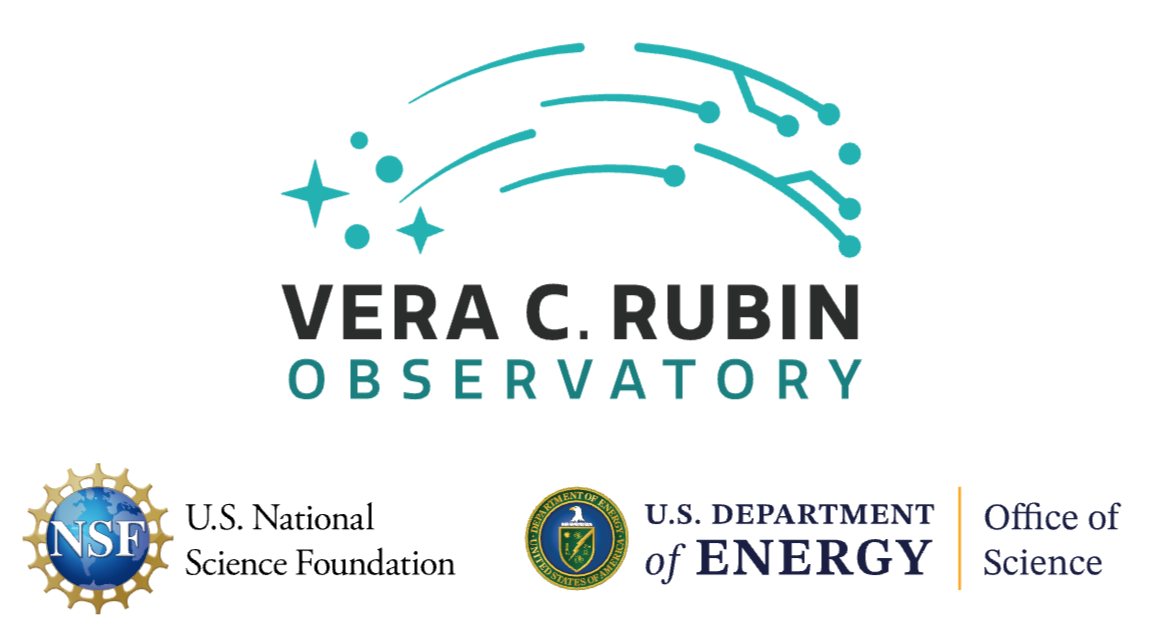

</div>

For the Rubin Science Platform at data.lsst.cloud. <br>
Data Release: <a href="https://dp1.lsst.io">Data Preview 1</a> <br>
Container Size: large <br>
LSST Science Pipelines version: r29.2.0 <br>
Last verified to run: 2025-10-31 <br>
Repository: <a href="https://github.com/lsst/tutorial-notebooks">github.com/lsst/tutorial-notebooks</a> <br>
DOI: <a href="https://doi.org/10.11578/rubin/dc.20250909.20">10.11578/rubin/dc.20250909.20</a> <br>

**Learning objective:** To explore DP1 stellar photometry in crowded fields.

**LSST data products:** `Object`, `ForcedSourceOnDiaObject`

**Packages:** `lsst.rsp.get_tap_service`

**Credit:**
Originally developed by the Rubin Community Science team. Please consider acknowledging them if this notebook is used for the preparation of journal articles, software releases, or other notebooks. 

**Get Support:**
Everyone is encouraged to ask questions or raise issues in the 
<a href="https://community.lsst.org/c/support">Support Category</a> 
of the Rubin Community Forum.
Rubin staff will respond to all questions posted there.

## 1. Introduction

Colin: to compute the 1D stellar number density profile, use "NOT_DEBLENDED" mask plane to compute areas to divide in each tract and patch.

This notebook demonstrates the challenges of crowded-field photometry in Rubin DP1 and shows the scientific potential of applying forced photometry in these regimes.

Crowded stellar fields are intrinsically difficult in ground-based data, and Rubin is no exception. Accurate flux measurements require careful treatment of blending, point-spread function fidelity, and local background estimation. In dense regions, stars overlap within a single PSF footprint, which increases confusion and introduces systematic biases that dominate over photon noise. Understanding where and how this transition occurs is essential for interpreting photometric precision and completeness. 

In DP1 processing, the LSST science pipelines may skip deblending when computational safeguards trigger. Typical triggers include very large parent footprints, too many detected peaks, single-peak parents that do not require deblending, or heavy masking. This failure mode reflects both crowding and flux contrast, not stellar density alone. A few bright stars can produce the same behavior as a dense field of faint ones. This highlights the difficulty of crowded-field photometry, which is not a primary optimization target of the DP1 precessing. When deblending is skipped, no subsequent flux measurements are produced for those sources. 

<div style="max-width:600px">

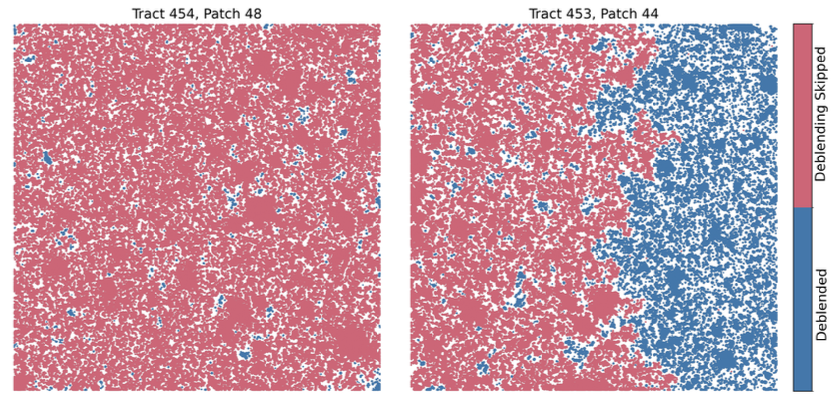

</div>

> **Figure 1:** The figure is adopted from [Choi et al. (2025)](https://ui.adsabs.harvard.edu/abs/2025ApJ...992...47C/abstract), comparing deblending outcomes for two example tract/patch pairs in the 47 Tuc field: (454, 48), which exhibits severe crowding, and (453, 44), which contains a mix of crowded and less crowded regions. Successfully deblended sources are shown in blue, while those where deblending was skipped for various reasons, including crowding, are shown in pink. 


**References:** [Choi et al. (2025)](https://ui.adsabs.harvard.edu/abs/2025ApJ...992...47C/abstract), [Wainer et al. (2025)](https://ui.adsabs.harvard.edu/abs/2025RNAAS...9..171W/abstract)

**Related tutorials:** See the 200-level DP1 tutorial on the deblender.

### 1.1. Import packages

Import `numpy`, a fundamental package for scientific computing with arrays in Python
(<a href="https://numpy.org">numpy.org</a>), 
`matplotlib`, a comprehensive library for data visualization
(<a href="https://matplotlib.org/">matplotlib.org</a>;
<a href="https://matplotlib.org/stable/gallery/index.html">matplotlib gallery</a>), and the `SkyCoord` class from <a href="https://docs.astropy.org/en/stable/coordinates/index.html">astropy.cooridates</a>.

From the LSST pacakge (<a href="https://pipelines.lsst.io/">pipelines.lsst.io</a>), import the RSP Table Access Protocol (TAP) service and the `DustValues` class from the `rubin_sim` package (<a href="https://rubin-sim.lsst.io/index.html">rubin_sim</a>).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.coordinates import SkyCoord, Galactocentric
import astropy.units as u
import os

from lsst.rsp import get_tap_service
from lsst.daf.butler import Butler
from rubin_sim.phot_utils import DustValues
import lsst.sphgeom as sphgeom

### 1.2. Define parameters and functions

Create an instance of the TAP service, and assert that it exists.

In [ ]:
service = get_tap_service("tap")
assert service is not None

In [ ]:
butler = Butler("dp1", collections="LSSTComCam/DP1")
assert butler is not None

Define a circular region with a 1-degree radius centered on the Fornax dSph field. (coordinates in degrees).

(example 1D profile: https://arxiv.org/pdf/1910.10134)

In [ ]:
ra_cen = 40.080
dec_cen = -34.450
radius = 1.0

region = sphgeom.Region.from_ivoa_pos(f"CIRCLE {ra_cen} {dec_cen} {radius}")

Set the environment variable RUBIN_SIM_DATA_DIR to /rubin/rubin_sim_data to make the current rubin_sim throughput data available.

In [ ]:
os.environ['RUBIN_SIM_DATA_DIR'] = '/rubin/rubin_sim_data'

List bands that are used in this notebook.

In [ ]:
bands = "gri"

Set font sizes globally for all subsequent matplotlib figures in this notebook.

In [ ]:
plt.rcParams["font.size"] = 15
plt.rcParams["figure.titlesize"] = 15
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["axes.titlesize"] = 12

## 2. Photometry in the `Object` table



### 2.1. Query for point-like objects

Query the `Object` table in the 47 Tuc field for coordinates, and PSF photometry in $gri$. Restrict to point sources (`refExtendedness` = 0).

In [ ]:
query = """
        SELECT coord_dec,coord_ra,deblend_failed,deblend_incompleteData,deblend_isolatedParent,deblend_iterations,
           deblend_logL,deblend_masked,deblend_nChild,deblend_nPeaks,deblend_parentTooBig,
           deblend_peak_center_x,deblend_peak_center_y,deblend_skipped,deblend_tooManyPeaks,
           detect_fromBlend,detect_isDeblendedModelSource,detect_isIsolated,g_blendedness,
           g_deblend_blendedness,g_deblend_dataCoverage,g_deblend_fluxOverlap,
           g_deblend_fluxOverlapFraction,g_psfMag,g_psfMagErr,i_psfMag,r_psfMag
        FROM dp1.Object
        WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec),
              CIRCLE('ICRS', {}, {}, {})) = 1
        AND refExtendedness = 0
        """.format(ra_cen, dec_cen, radius)

In [ ]:
job = service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()

Fetch the results, store them as a table.

In [ ]:
assert job.phase == 'COMPLETED'
objtab = job.fetch_result().to_table()

In [ ]:
objtab

### 2.2. Plots

Display spatial distribution of stars in the field and their CMDs.

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

im0 = axs[0].hist2d(objtab['coord_ra'], objtab['coord_dec'], bins=200, norm=LogNorm())
axs[0].invert_xaxis()
axs[0].set_xlabel('RA (deg)')
axs[0].set_ylabel('Dec (deg)')

im1 = axs[1].hist2d(objtab['g_psfMag']-objtab['r_psfMag'], objtab['r_psfMag'],
                    range=((-1,2.5),(14,27)), bins=200, norm=LogNorm())
axs[1].set_xlabel('g − r')
axs[1].set_ylabel('r')
axs[1].invert_yaxis()

im2 = axs[2].hist2d(objtab['g_psfMag']-objtab['r_psfMag'],
                    objtab['r_psfMag']-objtab['i_psfMag'],
                    range=((-1,2.5),(-1,2.5)), bins=200, norm=LogNorm())
axs[2].set_xlabel('g − r')
axs[2].set_ylabel('r − i')

plt.show()

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(121)
plt.scatter(objtab['g_psfMag']-objtab['i_psfMag'], objtab['g_psfMag'], c=objtab['g_blendedness'],
            s=3, vmin=0,vmax=0.1)
plt.ylim(29,14)
plt.colorbar()

plt.subplot(122)
plt.scatter(objtab['g_psfMag'], objtab['g_psfMagErr'], c=objtab['g_blendedness'],
            s=3, vmin=0,vmax=0.1)
plt.colorbar()
plt.ylim(0,0.5)

In [ ]:
query = "patch.region OVERLAPS region AND band='r'"
datasetrefs = butler.query_datasets("deep_coadd",
                                          where=query,
                                          bind={"region": region},
                                          with_dimension_records=True,
                                          )

In [ ]:
print(len(datasetrefs))

In [ ]:
# for ref in datasetrefs:
#     tract = ref.dataId["tract"]
#     patch = ref.dataId["patch"]
#     print(tract, patch)

tracts = {ref.dataId["tract"] for ref in datasetrefs}
patches = {ref.dataId["patch"] for ref in datasetrefs}

In [ ]:
ref = datasetrefs[10]
deep_coadd = butler.get(ref)

In [ ]:
mask = deep_coadd.getMask()

In [ ]:
# Find the bit number for the "NOT_DEBLENDED" plane
bit = mask.getMaskPlane('NOT_DEBLENDED')

# Create a boolean array: True where NOT_DEBLENDED is set
not_deblended = (mask.getArray() & (1 << bit)) != 0

In [ ]:
np.sum(not_deblended)

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(121)
plt.imshow(deep_coadd.getImage().array, vmax=100, aspect='auto')
plt.colorbar()

plt.subplot(122)
plt.imshow(deep_coadd.getImage().array*~not_deblended, vmax=100, aspect='auto')
plt.colorbar()